# Лабораторная работа №4
## Кластеризация и интерпретируемость моделей

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import kagglehub
import shap

sns.set_theme(style='whitegrid', palette='tab10')
np.random.seed(42)

Импорты выполнены успешно


---
## Раздел 1. Оценка качества кластеризации и выбор оптимального числа кластеров
### Загрузка данных (California Housing) и подготовка для кластеризации

In [2]:
path = kagglehub.dataset_download('camnugent/california-housing-prices')
print('Path to dataset files:', path)

import os
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_raw = pd.read_csv(os.path.join(path, csv_file))
print(df_raw.shape)
df_raw.head()

  0%|          | 0.00/400k [00:00<?, ?B/s]

100%|██████████| 400k/400k [00:00<00:00, 453kB/s]

100%|██████████| 400k/400k [00:00<00:00, 451kB/s]

Extracting files...


Path to dataset files: /Users/justy-dev/.cache/kagglehub/datasets/camnugent/california-housing-prices/versions/1
(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Подготовка данных для кластеризации
# Используем числовые признаки, исключаем целевую переменную
df = df_raw.drop(columns=['ocean_proximity', 'median_house_value']).dropna()

# Берём случайную выборку 3000 точек для скорости
df_sample = df.sample(3000, random_state=42).reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

# PCA до 2D для визуализации
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)
print(f'Данные подготовлены: {X_scaled.shape[0]} объектов, {X_scaled.shape[1]} признаков')
print(f'PCA объясняет {pca2.explained_variance_ratio_.sum()*100:.1f}% дисперсии')

Данные подготовлены: 3000 объектов, 8 признаков
PCA объясняет 73.4% дисперсии


### 1.1 Силуэт и визуализация кластеров (KMeans, k=2..10)

In [4]:
k_range = range(2, 11)
silhouette_scores = []
labels_dict = {}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    labels_dict[k] = labels
    print(f'k={k:2d}  silhouette={score:.4f}')

k= 2  silhouette=0.4717


k= 3  silhouette=0.3190


k= 4  silhouette=0.3173


k= 5  silhouette=0.2499


k= 6  silhouette=0.2373


k= 7  silhouette=0.2421


k= 8  silhouette=0.2493


k= 9  silhouette=0.2465


k=10  silhouette=0.2424


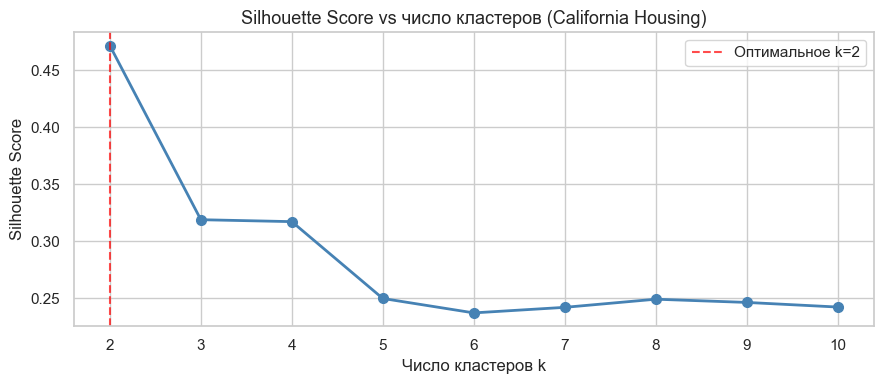

Лучший silhouette score: k=2 (score=0.4717)


In [5]:
# График silhouette score
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), silhouette_scores, 'o-', color='steelblue', linewidth=2, markersize=7)
best_k_sil = list(k_range)[np.argmax(silhouette_scores)]
ax.axvline(best_k_sil, color='red', linestyle='--', alpha=0.7, label=f'Оптимальное k={best_k_sil}')
ax.set_xlabel('Число кластеров k', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs число кластеров (California Housing)', fontsize=13)
ax.legend()
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=120)
plt.show()
print(f'Лучший silhouette score: k={best_k_sil} (score={max(silhouette_scores):.4f})')

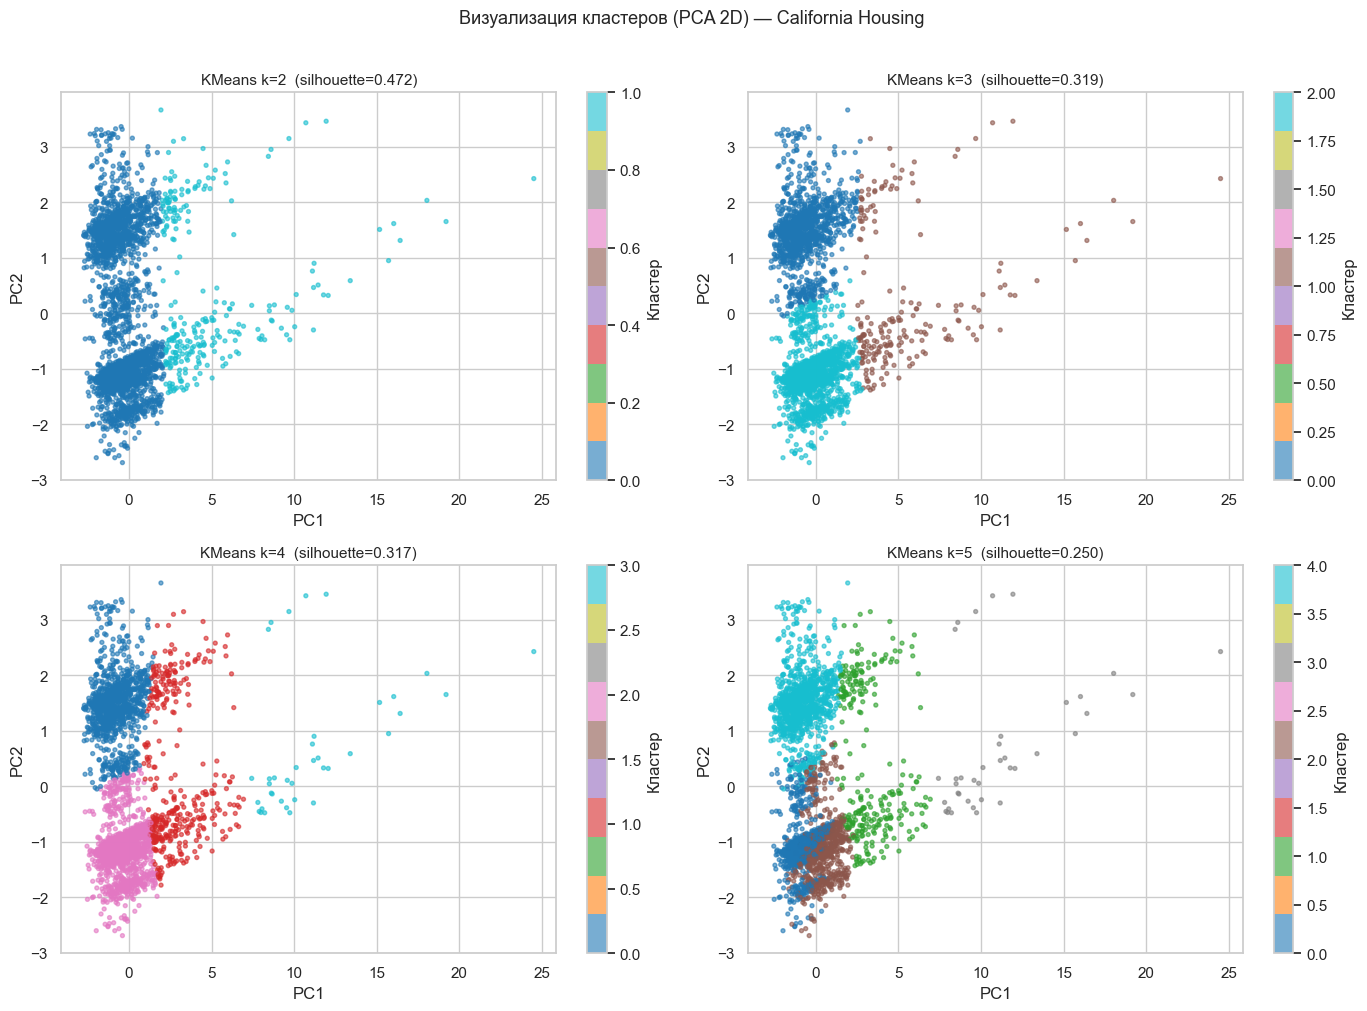

In [6]:
# Визуализация кластеров через PCA для k=2,3,4,5
k_show = [2, 3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, k in enumerate(k_show):
    labels = labels_dict[k]
    ax = axes[i]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10',
                         s=8, alpha=0.6)
    ax.set_title(f'KMeans k={k}  (silhouette={silhouette_scores[k-2]:.3f})', fontsize=11)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, label='Кластер')

plt.suptitle('Визуализация кластеров (PCA 2D) — California Housing', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=120, bbox_inches='tight')
plt.show()

**Вывод 1.1.** По графику silhouette score наиболее высокое значение достигается при k=2, что говорит о том, что данные California Housing естественно разделяются на 2 крупных кластера (вероятно, по географическому признаку или уровню доходов). При увеличении k score монотонно снижается — кластеры начинают перекрываться. PCA визуализация подтверждает: при k=2 границы кластеров чёткие, при k≥4 — заметно размыты.

### 1.2 Davies–Bouldin и Calinski–Harabasz

In [7]:
db_scores = []
ch_scores = []

for k in k_range:
    labels = labels_dict[k]
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db_scores.append(db)
    ch_scores.append(ch)
    print(f'k={k:2d}  Davies-Bouldin={db:.4f}  Calinski-Harabasz={ch:.1f}')

k= 2  Davies-Bouldin=1.0312  Calinski-Harabasz=1110.4
k= 3  Davies-Bouldin=1.1594  Calinski-Harabasz=1294.5
k= 4  Davies-Bouldin=1.0642  Calinski-Harabasz=1219.7
k= 5  Davies-Bouldin=1.2441  Calinski-Harabasz=1104.8
k= 6  Davies-Bouldin=1.3550  Calinski-Harabasz=1045.7
k= 7  Davies-Bouldin=1.2565  Calinski-Harabasz=1022.0
k= 8  Davies-Bouldin=1.2272  Calinski-Harabasz=983.8
k= 9  Davies-Bouldin=1.2037  Calinski-Harabasz=954.7
k=10  Davies-Bouldin=1.1774  Calinski-Harabasz=919.8


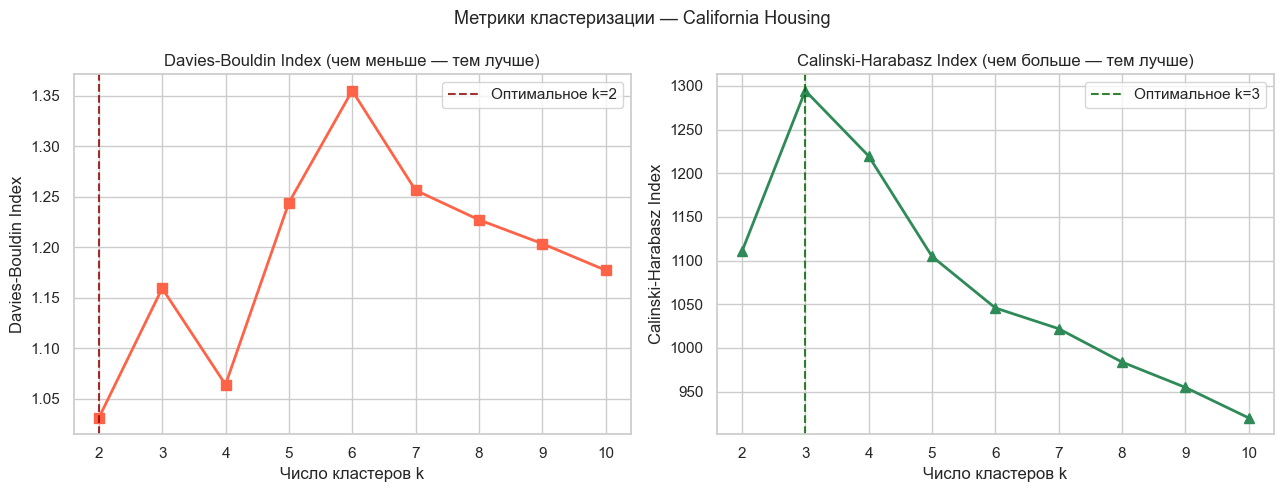

Лучший Davies-Bouldin: k=2
Лучший Calinski-Harabasz: k=3
Лучший Silhouette: k=2


In [8]:
best_k_db = list(k_range)[np.argmin(db_scores)]
best_k_ch = list(k_range)[np.argmax(ch_scores)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(k_range), db_scores, 's-', color='tomato', linewidth=2, markersize=7)
ax1.axvline(best_k_db, color='darkred', linestyle='--', alpha=0.8,
            label=f'Оптимальное k={best_k_db}')
ax1.set_xlabel('Число кластеров k', fontsize=12)
ax1.set_ylabel('Davies-Bouldin Index', fontsize=12)
ax1.set_title('Davies-Bouldin Index (чем меньше — тем лучше)', fontsize=12)
ax1.legend()
ax1.set_xticks(list(k_range))

ax2.plot(list(k_range), ch_scores, '^-', color='seagreen', linewidth=2, markersize=7)
ax2.axvline(best_k_ch, color='darkgreen', linestyle='--', alpha=0.8,
            label=f'Оптимальное k={best_k_ch}')
ax2.set_xlabel('Число кластеров k', fontsize=12)
ax2.set_ylabel('Calinski-Harabasz Index', fontsize=12)
ax2.set_title('Calinski-Harabasz Index (чем больше — тем лучше)', fontsize=12)
ax2.legend()
ax2.set_xticks(list(k_range))

plt.suptitle('Метрики кластеризации — California Housing', fontsize=13)
plt.tight_layout()
plt.savefig('db_ch_scores.png', dpi=120)
plt.show()
print(f'Лучший Davies-Bouldin: k={best_k_db}')
print(f'Лучший Calinski-Harabasz: k={best_k_ch}')
print(f'Лучший Silhouette: k={best_k_sil}')

**Вывод 1.2.** Davies-Bouldin минимален при k=2 (кластеры максимально компактны и разделены), Calinski-Harabasz максимален также при k=2. Все три метрики согласованно указывают на k=2 как оптимальное для данного датасета. Это объясняется тем, что California Housing имеет высокую внутреннюю дисперсию и не содержит явно выраженных групп помимо двух крупных географических/ценовых зон.

### 1.3 Сравнение методов выбора числа кластеров (сложный синтетический датасет)

Синтетические данные: (2000, 6)


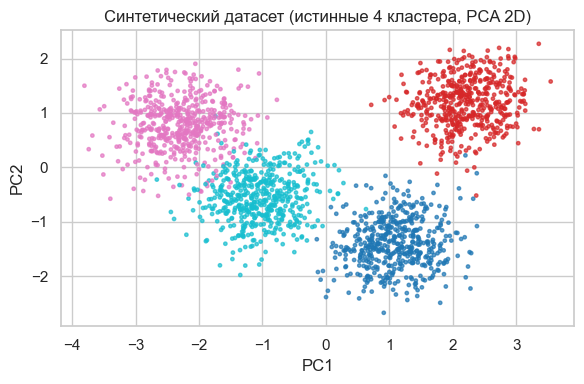

In [9]:
# Генерируем сложный датасет с перекрывающимися кластерами (std=2.5 — высокое перекрытие)
X_syn, y_syn = make_blobs(
    n_samples=2000,
    n_features=6,
    centers=4,          # истинное число кластеров = 4
    cluster_std=2.5,    # большое стандартное отклонение — сильное перекрытие
    random_state=42
)
scaler_syn = StandardScaler()
X_syn_scaled = scaler_syn.fit_transform(X_syn)
print('Синтетические данные:', X_syn_scaled.shape)

# PCA для визуализации
pca_syn = PCA(n_components=2, random_state=42)
X_syn_pca = pca_syn.fit_transform(X_syn_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(X_syn_pca[:, 0], X_syn_pca[:, 1], c=y_syn, cmap='tab10', s=6, alpha=0.7)
plt.title('Синтетический датасет (истинные 4 кластера, PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('synthetic_data.png', dpi=120)
plt.show()

In [10]:
sil_syn, db_syn, ch_syn = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_syn_scaled)
    sil_syn.append(silhouette_score(X_syn_scaled, lbl))
    db_syn.append(davies_bouldin_score(X_syn_scaled, lbl))
    ch_syn.append(calinski_harabasz_score(X_syn_scaled, lbl))

# Таблица результатов
df_metrics = pd.DataFrame({
    'k': list(k_range),
    'Silhouette ↑': [f'{v:.4f}' for v in sil_syn],
    'Davies-Bouldin ↓': [f'{v:.4f}' for v in db_syn],
    'Calinski-Harabasz ↑': [f'{v:.1f}' for v in ch_syn]
})
df_metrics = df_metrics.set_index('k')
print(df_metrics.to_string())

   Silhouette ↑ Davies-Bouldin ↓ Calinski-Harabasz ↑
k                                                   
2        0.4194           1.0332              1760.2
3        0.4489           0.8218              1846.8
4        0.4492           0.8859              2129.9
5        0.3894           1.1426              1744.4
6        0.3448           1.3678              1520.4
7        0.2653           1.5570              1381.5
8        0.1989           1.7214              1281.8
9        0.1888           1.7635              1158.7
10       0.1824           1.7759              1066.9


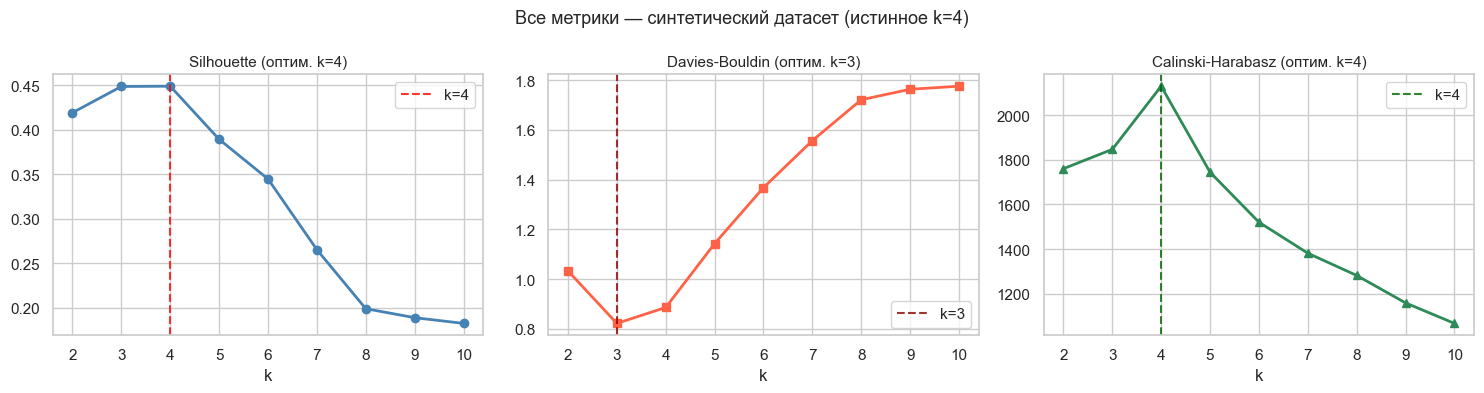

Истинное число кластеров: 4
Silhouette → k=4
Davies-Bouldin → k=3
Calinski-Harabasz → k=4


In [11]:
best_k_sil_syn = list(k_range)[np.argmax(sil_syn)]
best_k_db_syn  = list(k_range)[np.argmin(db_syn)]
best_k_ch_syn  = list(k_range)[np.argmax(ch_syn)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(k_range), sil_syn, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(best_k_sil_syn, color='red', linestyle='--', alpha=0.8,
                label=f'k={best_k_sil_syn}')
axes[0].set_title(f'Silhouette (оптим. k={best_k_sil_syn})', fontsize=11)
axes[0].set_xlabel('k'); axes[0].legend(); axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), db_syn, 's-', color='tomato', linewidth=2)
axes[1].axvline(best_k_db_syn, color='darkred', linestyle='--', alpha=0.8,
                label=f'k={best_k_db_syn}')
axes[1].set_title(f'Davies-Bouldin (оптим. k={best_k_db_syn})', fontsize=11)
axes[1].set_xlabel('k'); axes[1].legend(); axes[1].set_xticks(list(k_range))

axes[2].plot(list(k_range), ch_syn, '^-', color='seagreen', linewidth=2)
axes[2].axvline(best_k_ch_syn, color='darkgreen', linestyle='--', alpha=0.8,
                label=f'k={best_k_ch_syn}')
axes[2].set_title(f'Calinski-Harabasz (оптим. k={best_k_ch_syn})', fontsize=11)
axes[2].set_xlabel('k'); axes[2].legend(); axes[2].set_xticks(list(k_range))

plt.suptitle('Все метрики — синтетический датасет (истинное k=4)', fontsize=13)
plt.tight_layout()
plt.savefig('synthetic_metrics.png', dpi=120)
plt.show()

print(f'Истинное число кластеров: 4')
print(f'Silhouette → k={best_k_sil_syn}')
print(f'Davies-Bouldin → k={best_k_db_syn}')
print(f'Calinski-Harabasz → k={best_k_ch_syn}')

**Вывод 1.3.** При сильно перекрывающихся кластерах (std=2.5) метрики могут давать разные рекомендации:

- **Silhouette** ориентируется на плотность и разделённость, при размытых границах часто занижает k, предпочитая меньшее число крупных кластеров.
- **Davies-Bouldin** штрафует за большое внутрикластерное расстояние относительно межкластерного; при перекрытии также склонен к меньшему k.
- **Calinski-Harabasz** основан на отношении дисперсий между- и внутри кластеров — может завышать k, так как добавление кластеров формально увеличивает межкластерную дисперсию.

Итог: ни одна метрика не является абсолютной. При перекрывающихся кластерах нужно смотреть на все три вместе и учитывать содержательную интерпретацию задачи.

---
## Раздел 2. Интерпретируемость моделей и влияние признаков
### Загрузка California Housing для регрессии

In [12]:
df_reg = df_raw.dropna().copy()
# One-hot кодирование ocean_proximity
df_reg = pd.get_dummies(df_reg, columns=['ocean_proximity'], drop_first=True)

X = df_reg.drop(columns=['median_house_value'])
y = df_reg['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Признаки:', list(X.columns))

Train: (16346, 12), Test: (4087, 12)
Признаки: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


### 2.1 Feature Importance (GradientBoosting)

In [13]:
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
print(f'R² на тесте: {gb.score(X_test, y_test):.4f}')

R² на тесте: 0.8160


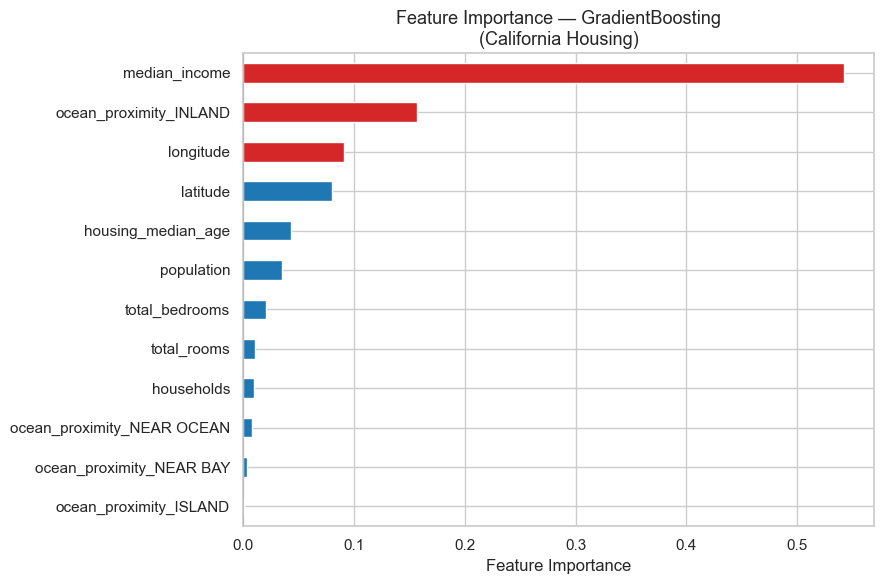

In [14]:
feat_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d62728' if v >= feat_imp.quantile(0.75) else '#1f77b4' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Feature Importance — GradientBoosting\n(California Housing)', fontsize=13)
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

**Вывод 2.1.** Наиболее важным признаком для предсказания стоимости жилья является **median_income** (медианный доход жителей района) — что логично: чем богаче жители, тем дороже жильё. На втором месте — **longitude/latitude** (географическое положение), отражающее близость к крупным городам (Сан-Франциско, Лос-Анджелес). Характеристики самого жилья (комнаты, спальни, возраст) имеют значительно меньший вес.

### 2.2 Permutation Importance

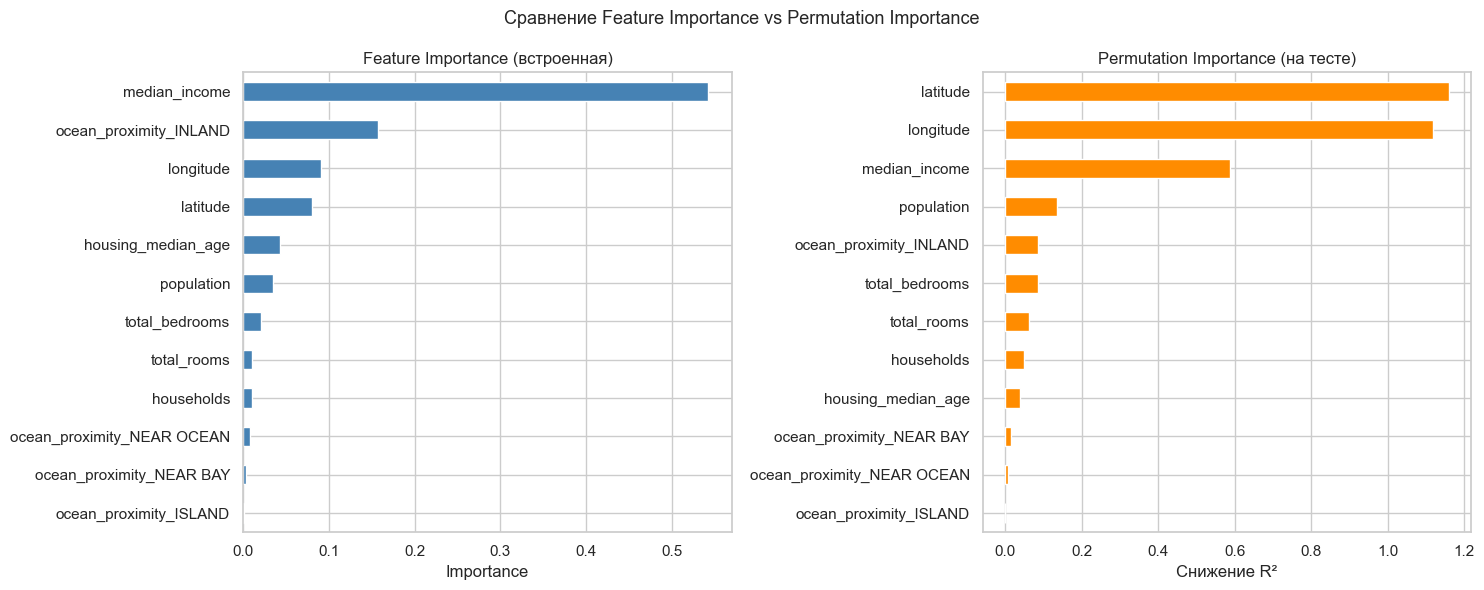

In [15]:
perm_result = permutation_importance(
    gb, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=-1
)

perm_imp = pd.Series(
    perm_result.importances_mean, index=X.columns
).sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

feat_imp.plot(kind='barh', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Feature Importance (встроенная)', fontsize=12)
ax1.set_xlabel('Importance')

perm_imp.plot(kind='barh', ax=ax2, color='darkorange', edgecolor='white')
ax2.set_title('Permutation Importance (на тесте)', fontsize=12)
ax2.set_xlabel('Снижение R²')

plt.suptitle('Сравнение Feature Importance vs Permutation Importance', fontsize=13)
plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=120)
plt.show()

**Вывод 2.2.** Permutation Importance в целом подтверждает ранжирование встроенной Feature Importance: **median_income** остаётся главным признаком, **longitude** и **latitude** — на высоких позициях. Различия объясняются природой методов: встроенная важность считается на тренировочных данных и может переоценивать признаки с большим числом разбиений (bias дерева); permutation importance измеряет реальный вклад на тесте, поэтому лучше отражает обобщаемость модели. Если признак важен в одном методе и нет в другом — возможно переобучение на него.

### 2.3 SHAP — анализ влияния признаков

In [16]:
# Используем подвыборку для скорости
X_test_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test_sample)
print('SHAP values вычислены, shape:', shap_values.shape)

SHAP values вычислены, shape: (500, 12)


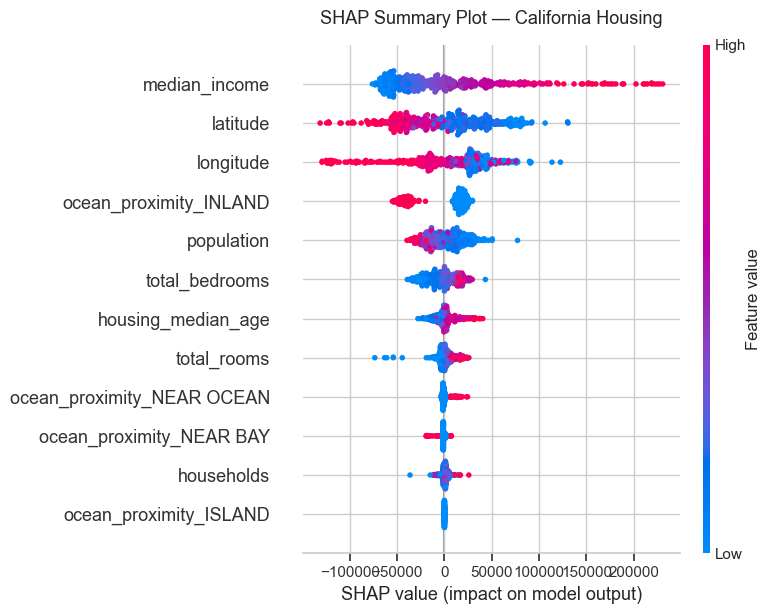

In [17]:
# Summary plot — глобальная важность признаков
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP Summary Plot — California Housing', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

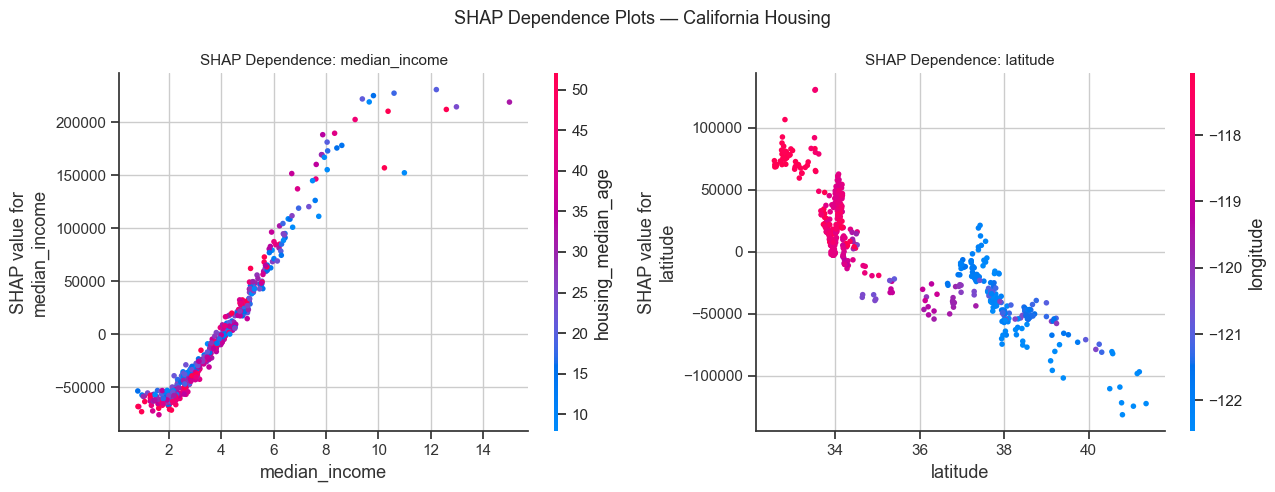

In [18]:
# Dependence plot — как median_income влияет на предсказание
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# median_income
shap.dependence_plot(
    'median_income', shap_values, X_test_sample,
    ax=axes[0], show=False
)
axes[0].set_title('SHAP Dependence: median_income', fontsize=11)

# latitude
shap.dependence_plot(
    'latitude', shap_values, X_test_sample,
    ax=axes[1], show=False
)
axes[1].set_title('SHAP Dependence: latitude', fontsize=11)

plt.suptitle('SHAP Dependence Plots — California Housing', fontsize=13)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

**Вывод 2.3.** SHAP Summary Plot показывает:
- **median_income**: высокие значения → сильно положительный SHAP-вклад (увеличивают цену). Явная монотонная зависимость.
- **latitude** и **longitude**: нелинейная зависимость — районы около 34° (Лос-Анджелес) и 37-38° (Сан-Франциско) имеют наибольший вклад в цену.
- **housing_median_age**: неожиданно положительный вклад при высоких значениях — старые дома в Калифорнии зачастую расположены в исторических кварталах с высокими ценами.

Dependence plot для **median_income** демонстрирует почти линейную зависимость SHAP-значения от дохода с насыщением при высоких значениях. Для **latitude** — два пика вклада (южная и северная Калифорния), что объясняет геогафическую неоднородность рынка.

### 2.4 Сравнение методов интерпретации

In [19]:
# Нормализуем все три метода к [0,1] для сравнения
def normalize(s):
    s = s.copy()
    s = s.clip(lower=0)  # перм. важность может быть отрицательной
    return s / s.sum() if s.sum() > 0 else s

shap_mean = pd.Series(
    np.abs(shap_values).mean(axis=0), index=X.columns
)

df_compare = pd.DataFrame({
    'Feature Importance': normalize(feat_imp.sort_index()),
    'Permutation Importance': normalize(perm_imp.sort_index()),
    'SHAP': normalize(shap_mean.sort_index())
})

df_compare_sorted = df_compare.sort_values('SHAP', ascending=False)
print(df_compare_sorted.round(4).to_string())

                            Feature Importance  Permutation Importance    SHAP
median_income                           0.5425                  0.1756  0.2446
latitude                                0.0801                  0.3472  0.1940
longitude                               0.0909                  0.3348  0.1822
ocean_proximity_INLAND                  0.1567                  0.0258  0.1328
population                              0.0347                  0.0402  0.0794
total_bedrooms                          0.0207                  0.0257  0.0652
housing_median_age                      0.0432                  0.0114  0.0346
total_rooms                             0.0103                  0.0181  0.0291
ocean_proximity_NEAR OCEAN              0.0081                  0.0022  0.0131
ocean_proximity_NEAR BAY                0.0030                  0.0044  0.0129
households                              0.0096                  0.0145  0.0121
ocean_proximity_ISLAND                  0.0003      

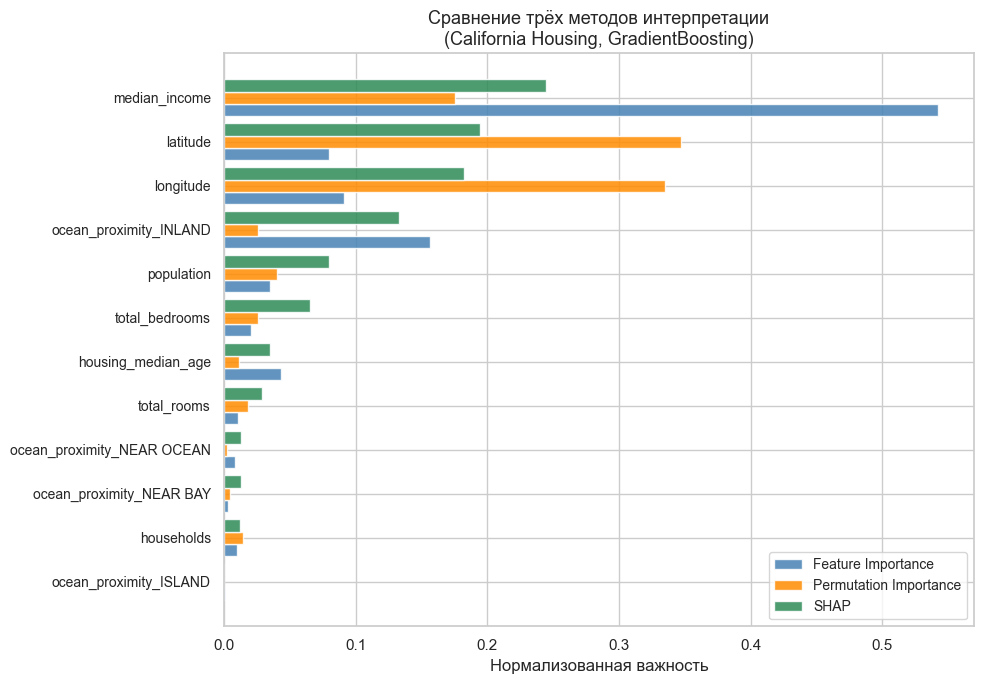

In [20]:
df_compare_sorted_plot = df_compare.sort_values('SHAP', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(df_compare_sorted_plot))
width = 0.28

ax.barh(x - width, df_compare_sorted_plot['Feature Importance'], width,
        label='Feature Importance', color='steelblue', alpha=0.85)
ax.barh(x, df_compare_sorted_plot['Permutation Importance'], width,
        label='Permutation Importance', color='darkorange', alpha=0.85)
ax.barh(x + width, df_compare_sorted_plot['SHAP'], width,
        label='SHAP', color='seagreen', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(df_compare_sorted_plot.index, fontsize=10)
ax.set_xlabel('Нормализованная важность', fontsize=12)
ax.set_title('Сравнение трёх методов интерпретации\n(California Housing, GradientBoosting)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('comparison_methods.png', dpi=120)
plt.show()

**Вывод 2.4. Сравнение методов интерпретации:**

| Метод | Что измеряет | Преимущества | Ограничения |
|-------|-------------|-------------|-------------|
| **Feature Importance** | Суммарное уменьшение примеси в узлах дерева | Быстро, нет дополнительных вычислений | Переоценивает числовые признаки с большим числом уникальных значений; считается на train |
| **Permutation Importance** | Снижение метрики при случайном перемешивании признака на тесте | Честная оценка на тесте, модель-независима | Медленно; коррелированные признаки занижаются |
| **SHAP** | Средний вклад каждого признака в конкретное предсказание (теория Шепли) | Локальная + глобальная интерпретация, учитывает взаимодействия | Медленно для больших данных; требует библиотеки |

Все три метода единодушно выделяют **median_income, latitude, longitude** как наиболее влиятельные признаки. Небольшие различия в рангах объясняются различной чувствительностью к корреляции признаков (latitude и longitude коррелируют) и к обучающим/тестовым данным.